In [1]:
# Taxi v3 PPO

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym

N = 256
class NeuralNetwork(nn.Module):
  def __init__(self, obs_size, act_size):
      super().__init__()
      self.affine = nn.Linear(obs_size, N)
      self.affine2 = nn.Linear(obs_size, N)
  #self.hidden = nn.Linear(N, N)
      self.action_head = nn.Linear(N, act_size)
      self.value_head = nn.Linear(N, 1)

  def forward(self, x):
      x1 = F.relu(self.affine(x))
      x2 = F.relu(self.affine2(x))
      prob = self.action_head(x1)
      value = self.value_head(x2)

      return prob, value

env = gym.make('Taxi-v3', render_mode="rgb_array")

model = NeuralNetwork(env.observation_space.n, env.action_space.n)
model.load_state_dict(torch.load("optimized.model"))

env.close()

In [3]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import torch

def get_policy(model, obs):
    logits = model(obs)[0]
    return torch.distributions.Categorical(logits=logits)
def get_action(model, obs):
    return get_policy(model, obs).sample().item()


def run(envname, model):
  env = gym.make(envname, render_mode="rgb_array")

  while True:
    observation, info = env.reset()
    env.render()

    for j in range(int(1e5)):
      obs = np.eye(env.observation_space.n)[observation]
      #action = get_policy(model, torch.as_tensor(obs, dtype=torch.float32)).probs.flatten().argmax().item()
      #print(action)
      action = get_action(model, torch.as_tensor(obs, dtype=torch.float32))
      observation, reward, terminated, truncated, info = env.step(action)
      
      clear_output(wait=True)
      plt.imshow( env.render())
      plt.show()
      if terminated or truncated:
          break

run('Taxi-v3', model)

ModuleNotFoundError: No module named 'matplotlib'

# Training

In [1]:
import taxi

In [2]:
model_sizes = [32,48,64,80,96]
eps = [0.01,0.05,0.1,0.15]
bs = [16,32,48,128]
gs = [0.95, 0.99, 0.995, 0.999, 0.9999]
lrs = [1e-5, 1e-4, 1e-3, 1e-2]
res = []
import torch
for random_seed in [399503, 50675, 149558, 86772, 103180, 991886, 832877, 247680, 420813, 85424, 761392, 843142]:
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    import numpy as np
    np.random.seed(random_seed)
    rh,lh,llh,model = taxi.train('Taxi-v3', N=256, g=0.999, lr=0.001, epsilon=0.2, batch_size=64, buf_size=1024, epoch=280, entropy=0.01, num_envs=4)
    res.append((rh,lh,llh,model))

-803
-857
-893
-776


/home/sunho/cliff.py:112: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/builder/dpetry/miniconda3/envs/pytorch-gpu/conda-bld/pytorch_1683022913808/work/torch/csrc/utils/tensor_new.cpp:230.)
  batch_obs = torch.as_tensor(batch_obs, dtype=torch.float32)


-650
-911
-731
-848
-96
-776
-848
-713
-785


KeyboardInterrupt: 

In [5]:
env = gym.make('Taxi-v3', render_mode="rgb_array")
model = res[0][3]
observation, info = env.reset()
env.render()

taxi_row, taxi_col, pass_idx, dest_idx = env.decode(observation)
for i in range(len(env.locs)):
    s = env.encode(env.locs[i][0], env.locs[i][1], 4, i)
    obs = np.eye(env.observation_space.n)[s]
    print("dest", i, "probs", get_policy(model, torch.as_tensor(obs, dtype=torch.float32)).probs)

for i in range(len(env.locs)):
    for j in range(len(env.locs)):
        if i == j:
            continue
        s = env.encode(env.locs[i][0], env.locs[i][1], i, j)
        obs = np.eye(env.observation_space.n)[s]
        print("pickup", i, "probs", get_policy(model, torch.as_tensor(obs, dtype=torch.float32)).probs)

IndexError: list index out of range

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


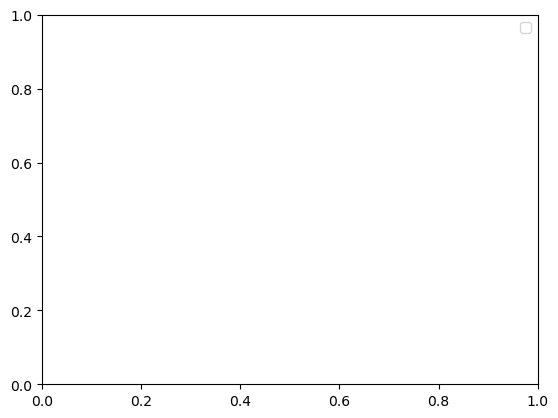

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size):
    weights = np.repeat(1.0, window_size) / window_size
    smoothed = np.convolve(data, weights, 'valid')
    return smoothed

# Assuming res is a list of (x, y) pairs
window_size = 10
for i in range(len(res)):
    smoothed_y = moving_average(res[i][0], window_size)
    plt.plot(smoothed_y, label=str(i))

plt.legend()
plt.show()


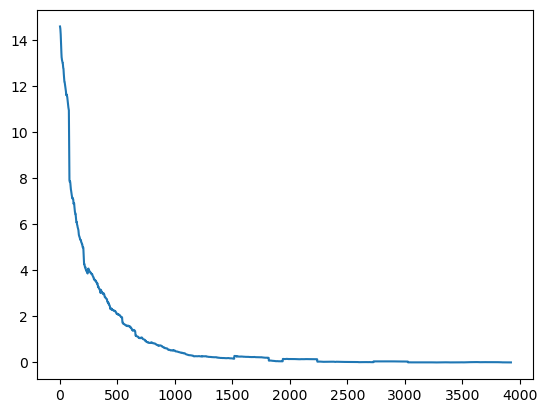

In [59]:
smoothed_y = moving_average(lh, 300)
plt.plot(smoothed_y)

In [51]:
torch.save(solved.state_dict(), "done.model")

In [60]:
import torch.nn as nn
import torch.nn.functional as F

N = 256
class NeuralNetwork(nn.Module):
  def __init__(self, obs_size, act_size):
      super().__init__()
      self.affine = nn.Linear(obs_size, N)
      self.affine2 = nn.Linear(obs_size, N)
  #self.hidden = nn.Linear(N, N)
      self.action_head = nn.Linear(N, act_size)
      self.value_head = nn.Linear(N, 1)

  def forward(self, x):
      x1 = F.relu(self.affine(x))
      x2 = F.relu(self.affine2(x))
      prob = self.action_head(x1)
      value = self.value_head(x2)

      return prob, value



bot = NeuralNetwork(env.observation_space.n, env.action_space.n)
bot.load_state_dict(torch.load("done.model"))

<All keys matched successfully>

In [61]:
rh,lh,llh,model = taxi.train('Taxi-v3', N=256, g=0.999, lr=0.001, epsilon=0.1, batch_size=128, buf_size=1024, epoch=5000, entropy=0.00, num_envs=16, loaded=bot)

10
8
7
8
12
5
6
13
5
3
6
8
7
6
11
8
4
8
6
9
4
7
8
8
9
6
8
7
12
9
7
14
7
9
6
4
5
9
5
8
6
8
7
8
10
10
5
10
5
6
11
5
7
7
4
3
7
5
4
9
12
5
5
9
9
5
10
6
6
9
11
3
11
10
8
6
8
7
5
4
7
7
5
8
7
8
6
7
4
6
14
8
7
4
9
11
10
6
6
9
5
9
9
5
11
4
7
9
4
8
10
9
13
6
6
3
7
9
7
14
6
10
9
10
6
5
6
10
7
7
14
9
5
8
7
1
7
8
10
8
12
5
9
4
8
9
7
12
12
5
10
7
7
11
7
8
5
7
5
7
10
9
13
8
5
10
14
11
11
6
10
6
8
5
8
11
7
8
11
6
12
7
12
1
6
4
9
7
4
6
6
10
9
10
11
7
7
2
7
11
9
8
5
7
9
3
11
8
5
9
11
8
3
5
7
12
7
9
6
13
6
7
3
8
6
13
6
10
13
5
6
11
11
7
6
9
9
6
4
4
8
13
15
11
6
11
10
11
10
10
5
4
5
11
8
6
10
4
14
4
3
5
7
9
9
8
8
10
7
10
12
9
3
10
14
6
11
10
5
9
5
6
5
7
5
6
4
4
4
8
7
8
6
5
10
8
4
5
9
6
9
11
10
9
10
5
8
13
7
10
8
4
10
7
10
10
11
10
4
10
10
10
5
6
10
8
10
5
10
6
5
4
6
8
11
8
8
9
4
12
9
11
5
5
10
13
6
9
5
9
7
5
11
11
8
8
12
9
6
5
7
11
13
5
9
11
9
8
11
7
10
3
14
5
8
12
9
14
5
3
9
10
10
10
7
6
6
7
7
10
7
7
10
7
8
3
3
4
6
7
8
6
9
7
14
11
6
9
9
9
7
6
9
7
9
8
14
6
12
4
9
4
7
6
7
5
5
5
7
7
7
7
8
13
9
6
5
9
8
12
4


In [63]:
torch.save(model.state_dict(), "optimized.model")
